# Problem statement:
Machine Failure Prediction Using Machine Learning for Predictive Maintenance  

- In industrial environments, unexpected machine failures can lead to production downtime, increased operational costs, and safety risks. Traditional maintenance strategies such as reactive maintenance (repair after failure) or scheduled maintenance (fixed time intervals) are inefficient and costly.
The objective of this project is to develop a machine learning classification model that can predict whether a machine is likely to fail or not .

In [22]:
# all libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sb


# ml libraries
from sklearn.preprocessing import StandardScaler, OrdinalEncoder
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, roc_curve, confusion_matrix, classification_report
from sklearn.compose import ColumnTransformer
from imblearn.pipeline import Pipeline
from imblearn.over_sampling import SMOTE

# models
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC


In [2]:
# dataset
data = pd.read_csv("C:\\Users\\rajka\\OneDrive\\Desktop\\Desktop_apps\\All Folders\\datasets\\predictive_maintenance_dataset.csv")
data


,UDI,Product ID,Type,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Machine failure,TWF,HDF,PWF,OSF,RNF
0,1,M14860,M,298.1,308.6,1551,42.8,0,0,0,0,0,0,0
1,2,L47181,L,298.2,308.7,1408,46.3,3,0,0,0,0,0,0
2,3,L47182,L,298.1,308.5,1498,49.4,5,0,0,0,0,0,0
3,4,L47183,L,298.2,308.6,1433,39.5,7,0,0,0,0,0,0
4,5,L47184,L,298.2,308.7,1408,40.0,9,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9995,9996,M24855,M,298.8,308.4,1604,29.5,14,0,0,0,0,0,0
9996,9997,H39410,H,298.9,308.4,1632,31.8,17,0,0,0,0,0,0
9997,9998,M24857,M,299.0,308.6,1645,33.4,22,0,0,0,0,0,0
9998,9999,H39412,H,299.0,308.7,1408,48.5,25,0,0,0,0,0,0


# Prepare data for models

### drop irrelevant features or other features  - these are the features which tell which kind of the failure happend when machine failed so they are not input features so we will drop them
TWF → Tool Wear Failure
→ Machine failed because the tool became too worn out.

HDF → Heat Dissipation Failure
→ Machine failed because temperature got too high (cooling couldn’t handle heat).

PWF → Power Failure
→ Machine failed due to abnormal power usage (too much or too little power).

OSF → Overstrain Failure
→ Machine failed because of excessive mechanical stress/overload.

RNF → Random Failure
→ Failure happened randomly (not linked to measured conditions).

In [3]:
data.drop(columns =['UDI','Product ID','TWF','HDF','PWF','OSF','RNF'],axis = 1,inplace = True)

In [4]:
# # simply map values for the type feature if not used in pipeline ---> don't execute this cell if pipeline will be created
# data['Type'] = data['Type'].map({'L':0,'M':1,'H':2})

In [5]:
#handle categorical feature
data['Type'] = data['Type'].map({'L':0,'M':1,'H':2})

In [6]:
# input and target feature selecting
X = data.drop('Machine failure', axis = 1)
y = data['Machine failure']

In [7]:
# split training and testing data
x_train,x_test,y_train,y_test =train_test_split(X, y, test_size =0.2,random_state = 42, stratify =y)

In [38]:
scaler = StandardScaler()
smote = SMOTE(random_state =42,sampling_strategy =0.5)

In [9]:
# # scale the features 
# x_train_scaled = scaler.fit_transform(x_train)
# x_test_scaled = scaler.transform(x_test)

In [10]:
# # use SMOTE to handle imbalanced dataset
# x_train_smt,y_train_smt = smote.fit_resample(x_train_scaled,y_train)

### Models

In [49]:
lr = LogisticRegression(penalty = 'l2',solver ='lbfgs',C =1.5) #with smote

svm = SVC(kernel ='rbf', C = 1, gamma ='scale')  # with smote

dt = DecisionTreeClassifier(class_weight ='balanced',max_depth =7,criterion = 'gini', random_state =42,min_samples_split =15,min_samples_leaf =10)

rf = RandomForestClassifier(class_weight='balanced',n_estimators = 200,random_state =42,min_samples_split = 15,min_samples_leaf =10)

### use imbalance pipeline to apply multiple transformations collectively

In [47]:
lr_pipe = Pipeline([
    ('scaling',scaler),
    ('smote',smote),
    ('Logistic model',lr)
])

lr_pipe.fit(x_train,y_train)
lr_train_pred = lr_pipe.predict(x_train)
lr_test_pred = lr_pipe.predict(x_test)


In [48]:
svm_pipe = Pipeline([
    ('scaling',scaler),
    ('smote',smote),
    ('svm model',svm)
])

svm_pipe.fit(x_train,y_train)
svm_train_pred = svm_pipe.predict(x_train)
svm_test_pred = svm_pipe.predict(x_test)


In [50]:
dt_pipe  = Pipeline([
    ('decision tree model',dt)
])

dt_pipe.fit(x_train,y_train)
dt_train_pred = dt_pipe.predict(x_train)
dt_test_pred = dt_pipe.predict(x_test)
lr_prob = lr_pipe.predict_proba(x_test)[:,1]

In [51]:
rf_pipe  = Pipeline([
    ('random forest model',rf)
])

rf_pipe.fit(x_train,y_train)
rf_train_pred = rf_pipe.predict(x_train)
rf_test_pred = rf_pipe.predict(x_test)

### Evaluation

In [33]:
result = {}
def evaluate_model(model_name,y_train,y_test,y_train_pred,y_pred):
    print(f'\n{model_name} Evaluation\n')
    train_accuracy =accuracy_score(y_train,y_train_pred)
    test_accuracy =accuracy_score(y_test,y_pred)
    precision =precision_score(y_test,y_pred)
    recall = recall_score(y_test,y_pred)
    f1= f1_score(y_test,y_pred)
   
    # store the all metrices score in dictionary to use in dataframe later
    result[model_name] = {
        'Train_Accuracy' :train_accuracy,
        'Test_Accuracy': test_accuracy,
        'Precision': precision,
        'Recall': recall,
        'f1_score': f1,
    }

    print(f'\nname {model_name}')
    print(f'Train Accuracy: {train_accuracy}')
    print(f'Test Accuracy: {test_accuracy}')
    print(f'Precision score: {precision}')
    print(f'Recall score: {recall}')
    print(f'f1_score : {f1}')
    print('\nConfusion Matrix\n',confusion_matrix(y_test,y_pred))
    print('\n\nClassification Report\n',classification_report(y_test,y_pred))


In [52]:
print('Logistic regression pipeline')
evaluate_model('lr',y_train,y_test,lr_train_pred,lr_test_pred)

print('SVM pipeline')
evaluate_model('svm',y_train,y_test,svm_train_pred,svm_test_pred)

print('decision tree pipeline')
evaluate_model('dt',y_train,y_test,dt_train_pred,dt_test_pred)

print('random forest pipeline')
evaluate_model('rf',y_train,y_test,rf_train_pred,rf_test_pred)

Logistic regression pipeline

lr Evaluation


name lr
Train Accuracy: 0.898
Test Accuracy: 0.8995
Precision score: 0.2170212765957447
Recall score: 0.75
f1_score : 0.33663366336633666

Confusion Matrix
 [[1748  184]
 [  17   51]]


Classification Report
               precision    recall  f1-score   support

           0       0.99      0.90      0.95      1932
           1       0.22      0.75      0.34        68

    accuracy                           0.90      2000
   macro avg       0.60      0.83      0.64      2000
weighted avg       0.96      0.90      0.92      2000

SVM pipeline

svm Evaluation


name svm
Train Accuracy: 0.954625
Test Accuracy: 0.949
Precision score: 0.3881578947368421
Recall score: 0.8676470588235294
f1_score : 0.5363636363636364

Confusion Matrix
 [[1839   93]
 [   9   59]]


Classification Report
               precision    recall  f1-score   support

           0       1.00      0.95      0.97      1932
           1       0.39      0.87      0.54        68

### Compare all models stats, parameters

In [53]:
result_df = pd.DataFrame(result).T.sort_values(by = 'Test_Accuracy',ascending = False)
result_df

,Train_Accuracy,Test_Accuracy,Precision,Recall,f1_score
rf,0.967375,0.9630,0.475410,0.852941,0.610526
svm,0.954625,0.9490,0.388158,0.867647,0.536364
dt,0.949250,0.9455,0.369427,0.852941,0.515556
lr,0.898000,0.8995,0.217021,0.750000,0.336634


Conclusion - Best Model with high accuracy, recall  ---> Random Forest

### Roc auc curve

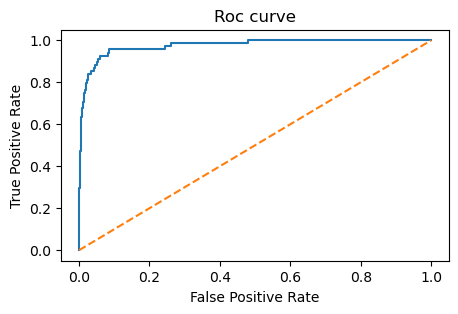

In [60]:
rf_prob = rf_pipe.predict_proba(x_test)[:,1]
fpr, tpr,_ = roc_curve(y_test,rf_prob)   ## compare the false positive and true positive rate

plt.figure(figsize =(5,3))
plt.plot(fpr,tpr)
plt.plot([0,1],[0,1],'--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Roc curve')
plt.show()

### Analyze important features

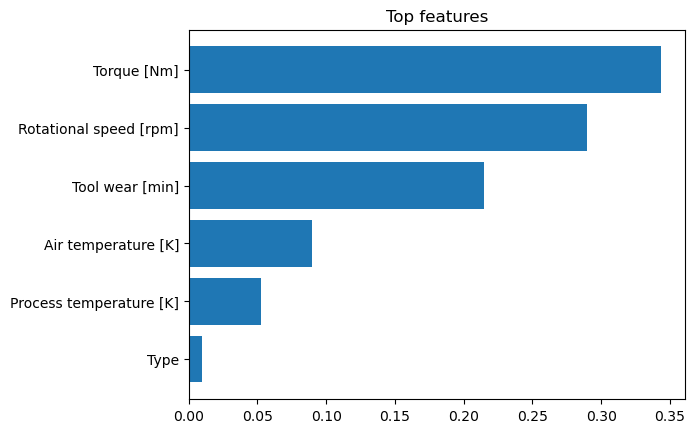

In [66]:
rf_model = rf_pipe.named_steps['random forest model']
importances = rf_model.feature_importances_
indices = np.argsort(importances)[-10:]

plt.barh(range(len(indices)),importances[indices])
plt.yticks(range(len(indices)),X.columns[indices])
plt.title('Top features')
plt.show()

### Cross validation

In [75]:
from sklearn.model_selection import StratifiedKFold, cross_val_score

cv = StratifiedKFold(n_splits =5, shuffle = True, random_state =42)
cv_roc_auc = cross_val_score(rf_pipe,x_train,y_train, cv =cv,scoring ='roc_auc')
cv_accuracy = cross_val_score(rf_pipe,x_train,y_train,cv =cv,scoring= 'accuracy')
cv_recall = cross_val_score(rf_pipe,x_train,y_train,cv =cv,scoring= 'recall')

print('Cross validation roc auc:', cv_roc_auc)
print('Cross validation accuracy:', cv_accuracy)
print('Cross validation recall:', cv_recall)

Cross validation roc auc: [0.98548225 0.9732284  0.95792008 0.98372143 0.9563048 ]
Cross validation accuracy: [0.958125 0.961875 0.956875 0.96625  0.95375 ]
Cross validation recall: [0.92592593 0.83333333 0.81481481 0.81481481 0.83636364]


### Base Model Compariosn

### Save Model using pickle

In [78]:
import pickle
pickle.dump(rf_pipe,open('Predictive_maintenance_model.pkl','wb'))

### Load saved model

In [79]:
with open('Predictive_maintenance_model.pkl','rb') as file:
    model= pickle.load(file)

### Test Model on unseen data

make predictions

In [115]:
print(model.predict([data.iloc[161,:6]]))  ## Actually machine failure =1 
print(model.predict([data.iloc[54,:6]])) ## actually  = 0

[1]
[0]


D:\miniconda\Lib\site-packages\sklearn\base.py:493: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(
D:\miniconda\Lib\site-packages\sklearn\base.py:493: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(
